Step 1: Import Libraries and Generate Noisy Linear Data


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.randint(0, 10, 10)
x = x.reshape(-1, 1)
noise = np.random.normal(size=x.shape)
y = 2 * x + 1 + noise


Step 2: Define the Cost Function (Mean Squared Error)
This function returns how far off our predictions are from the actual values — the lower the cost, the better the model.

In [ ]:
def compute_cost(x, y, w, b):
    m = len(y)               # m is the number of training examples
    y_pred = x.dot(w) + b    # Linear prediction: ŷ = wx + b
    cost = (1/(2*m)) * np.sum((y_pred - y)**2)   # Mean Squared Error (MSE) cost function
    return cost


Step 3: Compute Gradients (Partial Derivatives of Cost Function)
These gradients tell the algorithm how to change w and b to reduce the cost.

In [ ]:
def compute_gradient(x, y, w, b):
    m = len(y)     # Number of samples
    y_pred = x.dot(w) + b
    error = y_pred - y
    dw = (1/m) * x.T.dot(error)  # Partial derivative of cost w.r.t. weight (w)
    db = (1/m) * np.sum(error)   # Partial derivative of cost w.r.t. bias (b)
    return dw, db


Step 4: Perform Gradient Descent to Minimize the Cost Function
The loop gradually adjusts the model parameters to fit the data better by following the slope of the cost function.

In [ ]:
def gradient_descent(x, y, w, b, learning_rate, iterations):
    cost_list = []    # To store the cost at each iteration
    for i in range(iterations):
        dw, db = compute_gradient(x, y, w, b)  # Compute gradients
        w -= learning_rate * dw
        b -= learning_rate * db
        cost = compute_cost(x, y, w, b)     # Compute new cost
        cost_list.append(cost)
    return w, b, cost_list


Step 5: Visualize the Cost History and the Fitted Line


Weight: [[2.01619891]]
Bias: 0.5047200281329244


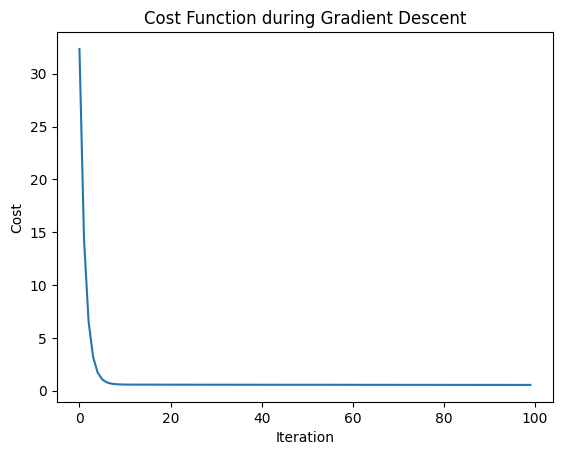

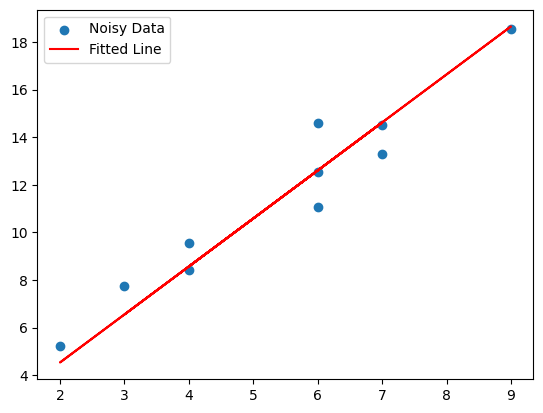

In [ ]:
w = np.zeros((1, 1))
b = 0
learning_rate = 0.01
iterations = 100

w_final, b_final, cost_history = gradient_descent(x, y, w, b, learning_rate, iterations)

print("Weight:", w_final)
print("Bias:", b_final)

plt.plot(cost_history)   # Plot cost at each iteration
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function during Gradient Descent")
plt.show()


plt.scatter(x, y, label="Noisy Data")   # Original data
y_pred = x.dot(w_final) + b_final       # Predicted line using final parameters
plt.plot(x, y_pred, color="red", label="Fitted Line")
plt.legend()
plt.show()
